 Here, we are going to analyze an Uber dataset to identify correlations between different variables. We will use Python with libraries such as pandas, matplotlib, and numpy for data manipulation and visualization.


In [2]:
#Install libraries
%pip install pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Import cleaned data files
import os

#print current working directory
print(os.getcwd())
#change directory to where the cleaned data files are located
os.chdir('/workspaces/uber.data/csv_files')
#print current working directory
print(os.getcwd())

/workspaces/uber.data/csv_files
/workspaces/uber.data/csv_files


In [5]:
# Create data frame
df = pd.read_csv('cleaned_uber_data.csv', index_col=0)
print(df)
print(df.info())
print("Available columns:", df.columns.tolist())

                Time    booking_ID   Booking_Status   Customer_ID  \
Date                                                                
2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   
...              ...           ...              ...           ...   
2024-11-11  19:34:01  "CNR6500631"        Completed  "CID4337371"   
2024-11-24  15:55:09  "CNR2468611"        Completed  "CID2325623"   
2024-09-18  10:55:15  "CNR6358306"        Completed  "CID9925486"   
2024-10-05  07:53:34  "CNR3030099"        Completed  "CID9415487"   
2024-03-10  15:38:03  "CNR3447390"        Completed  "CID4108667"   

             Vehicle_Type         Pickup_Location      Drop_Location  \
Date                          

  Test correlation between driver ratings and booking value:


In [6]:
correlation = df[df.columns[df.columns.str.lower().str.replace(' ', '_') == 'booking_value'][0]].corr(
	df[df.columns[df.columns.str.lower().str.replace(' ', '_') == 'driver_ratings'][0]]
)

print(f"Correlation between Driver Ratings and Booking Value: {correlation}")

#The Pearson correlation between driver ratings and booking value was -0.0002, close to 0, indicating no meaningful relationship.

Correlation between Driver Ratings and Booking Value: -0.00023744569495688121


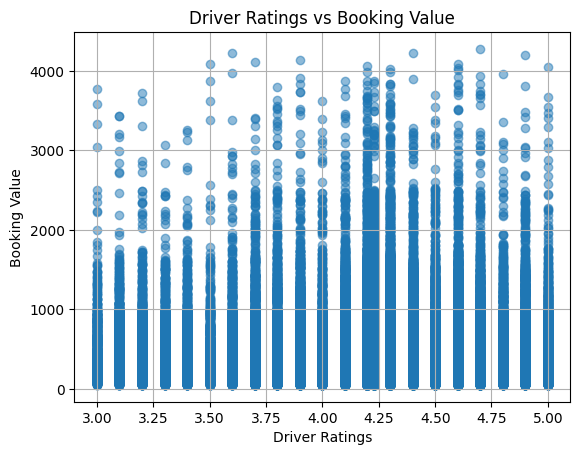

In [7]:
# Scatter plot between driver ratings and booking value to test again if correlation exists between the two

# Use the exact column names as printed above
plt.scatter(
    df[df.columns[df.columns.str.lower().str.replace(' ', '_') == 'driver_ratings'][0]],
    df[df.columns[df.columns.str.lower().str.replace(' ', '_') == 'booking_value'][0]],
    alpha=0.5
)
plt.title('Driver Ratings vs Booking Value')
plt.xlabel('Driver Ratings')
plt.ylabel('Booking Value')
plt.grid(True)
plt.show()
#The scatter plot shows no clear pattern, supporting the conclusion of no significant correlation between driver ratings and booking value. 

 Let's see the overall correlations in the dataset.


In [8]:
# Find the pearson correlations matrix for numeric columns only
corr = df.select_dtypes(include=[np.number]).corr(method='pearson')
corr

,Avg_VTAT,Avg_CTAT,Cancelled_Rides_by_Customer,Cancelled_Rides_by_Driver,Incomplete_Rides,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
Avg_VTAT,1.000000,0.052300,NaN,NaN,NaN,0.001900,0.052999,-0.004411,-0.003200
Avg_CTAT,0.052300,1.000000,NaN,NaN,NaN,0.000216,0.101503,0.000749,0.000928
Cancelled_Rides_by_Customer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancelled_Rides_by_Driver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Incomplete_Rides,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking_Value,0.001900,0.000216,NaN,NaN,NaN,1.000000,0.005174,-0.000237,-0.000274
Ride_Distance,0.052999,0.101503,NaN,NaN,NaN,0.005174,1.000000,-0.001767,0.004256
Driver_Ratings,-0.004411,0.000749,NaN,NaN,NaN,-0.000237,-0.001767,1.000000,-0.001010
Customer_Rating,-0.003200,0.000928,NaN,NaN,NaN,-0.000274,0.004256,-0.001010,1.000000


 Since the dataset does not contain any strong correlations (all values are close to 0), we can conclude that there are no significant linear relationships between the numeric variables in this Uber dataset. There is no need for linear regression without vaues that strongly correlate.


 **Logistic testing and regression**

In [9]:
#Install sklearn for logistic regression
%pip install scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay

Note: you may need to restart the kernel to use updated packages.


 Encode Categorical Features for Logistic Regression


In [10]:
#  Load dataset
df = pd.read_csv("cleaned_uber_data.csv")

# we want to predict whether drving a sedan leads to high booking value rides (> $508.29 (the avg))
df['high_value'] = (df['Booking_Value'] > 508.29).astype(int)
# Convert 'Vehicle_Type' to a binary variable: 1 if 'Sedan', else 0
df['is_sedan'] = (df['Vehicle_Type'] == 'Sedan').astype(int)    

X = df[['is_sedan', 'Booking_Value']]
y = df['high_value']

 Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

 Fit Logistic Regression

In [12]:
# Check class distribution in y_train
print("y_train value counts:\n", y_train.value_counts())

# If only one class is present, model fitting will fail.
if y_train.nunique() < 2:
	raise ValueError("y_train contains only one class. Please check your data split or threshold for 'high_value'.")
else:
	model = LogisticRegression(max_iter=1000)
	model.fit(X_train, y_train)

y_train value counts:
 high_value
1    60507
0    44493
Name: count, dtype: int64


 Evaluate Performance

Confusion Matrix:
[[19044    24]
 [    0 25932]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19068
           1       1.00      1.00      1.00     25932

    accuracy                           1.00     45000
   macro avg       1.00      1.00      1.00     45000
weighted avg       1.00      1.00      1.00     45000



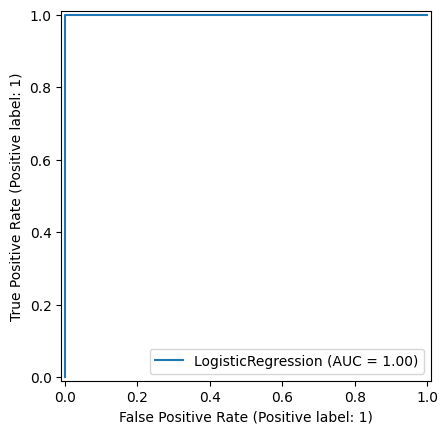

In [13]:
y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()

 Print coefficients to see which values contribute to high/low rating

In [14]:
coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs.sort_values())
#!/usr/bin/env python3  

is_sedan          0.000000
Booking_Value    14.279972
dtype: float64


 Check class balance and cross-validate

In [15]:
df['is_sedan'].value_counts()
df.groupby('is_sedan')['high_value'].mean()

is_sedan
0    0.57626
Name: high_value, dtype: float64